# Project Python Foundations: FoodHub Data Analysis

### Context

The number of restaurants in New York is increasing day by day. Lots of students and busy professionals rely on those restaurants due to their hectic lifestyles. Online food delivery service is a great option for them. It provides them with good food from their favorite restaurants. A food aggregator company FoodHub offers access to multiple restaurants through a single smartphone app.

The app allows the restaurants to receive a direct online order from a customer. The app assigns a delivery person from the company to pick up the order after it is confirmed by the restaurant. The delivery person then uses the map to reach the restaurant and waits for the food package. Once the food package is handed over to the delivery person, he/she confirms the pick-up in the app and travels to the customer's location to deliver the food. The delivery person confirms the drop-off in the app after delivering the food package to the customer. The customer can rate the order in the app. The food aggregator earns money by collecting a fixed margin of the delivery order from the restaurants.

### Objective

The food aggregator company has stored the data of the different orders made by the registered customers in their online portal. They want to analyze the data to get a fair idea about the demand of different restaurants which will help them in enhancing their customer experience. Suppose you are hired as a Data Scientist in this company and the Data Science team has shared some of the key questions that need to be answered. Perform the data analysis to find answers to these questions that will help the company to improve the business.

### Data Description

The data contains the different data related to a food order. The detailed data dictionary is given below.

### Data Dictionary

* order_id: Unique ID of the order
* customer_id: ID of the customer who ordered the food
* restaurant_name: Name of the restaurant
* cuisine_type: Cuisine ordered by the customer
* cost_of_the_order: Cost of the order
* day_of_the_week: Indicates whether the order is placed on a weekday or weekend (The weekday is from Monday to Friday and the weekend is Saturday and Sunday)
* rating: Rating given by the customer out of 5
* food_preparation_time: Time (in minutes) taken by the restaurant to prepare the food. This is calculated by taking the difference between the timestamps of the restaurant's order confirmation and the delivery person's pick-up confirmation.
* delivery_time: Time (in minutes) taken by the delivery person to deliver the food package. This is calculated by taking the difference between the timestamps of the delivery person's pick-up confirmation and drop-off information

### Let us start by importing the required libraries

In [ ]:
# Installing the libraries with the specified version.
!pip install numpy==1.25.2 pandas==1.5.3 matplotlib==3.7.1 seaborn==0.13.1 -q --user

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 58.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.


**Note**:
- After running the above cell, kindly restart the runtime (for Google Colab) or notebook kernel (for Jupyter Notebook), and run all cells sequentially from the next cell.
- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in ***this notebook***.

In [8]:
# import libraries for data manipulation
import numpy as np
import pandas as pd

# import libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

### Understanding the structure of the data

In [6]:
# uncomment and run the below code snippets if the dataset is present in the Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [9]:
# Write your code here to read the data
df = pd.read_csv('/content/drive/MyDrive/AIML/foodhub_order.csv');

In [ ]:
# Write your code here to view the first 5 rows
df.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24


### **Question 1:** How many rows and columns are present in the data? [0.5 mark]

In [ ]:
# Write your code here
df.shape

(1898, 9)

#### Observations:
* The dataset contains 9 columns and 1,898 records.

### **Question 2:** What are the datatypes of the different columns in the dataset? (The info() function can be used) [0.5 mark]

In [ ]:
# Write your code here
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   object 
 3   cuisine_type           1898 non-null   object 
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   object 
 6   rating                 1898 non-null   object 
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 133.6+ KB


#### Observations:
*  The dataset contains 9 columns and 1,898 records.
*  No missing values — all columns have 1,898 non-null entries.
* The dataset is largely clean and analysis-ready.
* Minor data cleaning (especially for rating) may be needed.








### **Question 3:** Are there any missing values in the data? If yes, treat them using an appropriate method. [1 mark]

In [ ]:
# Write your code here
# Replace "Not given" with NaN
df['rating'] = df['rating'].replace('Not given', np.nan)

df.head()


,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,NaN,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,NaN,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24


#### Observations:
* There are no blank or NaN cells, but the rating column contains "Not given", which represents a missing value in disguised (text) form.
* All other columns have valid entries.

**Conclusion**:
Only the rating column has missing values, represented as "Not given".

### **Question 4:** Check the statistical summary of the data. What is the minimum, average, and maximum time it takes for food to be prepared once an order is placed? [2 marks]

In [ ]:
# Write your code here

# Numerical columns summary
df.describe()

,order_id,customer_id,cost_of_the_order,food_preparation_time,delivery_time
count,1.898000e+03,1898.000000,1898.000000,1898.000000,1898.000000
mean,1.477496e+06,171168.478398,16.498851,27.371970,24.161749
std,5.480497e+02,113698.139743,7.483812,4.632481,4.972637
min,1.476547e+06,1311.000000,4.470000,20.000000,15.000000
25%,1.477021e+06,77787.750000,12.080000,23.000000,20.000000
50%,1.477496e+06,128600.000000,14.140000,27.000000,25.000000
75%,1.477970e+06,270525.000000,22.297500,31.000000,28.000000
max,1.478444e+06,405334.000000,35.410000,35.000000,33.000000


In [ ]:
# Non-numerical columns summary
df.describe(include=['object'])

,restaurant_name,cuisine_type,day_of_the_week,rating
count,1898,1898,1898,1162
unique,178,14,2,3
top,Shake Shack,American,Weekend,5
freq,219,584,1351,588


#### Observations:
* Cost of order: Most orders fall between $12–$22; expensive orders are outliers.

* Preparation and delivery times: Clustered around median (27 min prep, 25 min delivery); few extreme values.

* Average order cost is $16.50; could analyze high-value orders separately.

* Average prep and delivery times (~27 min and ~24 min) can guide restaurant efficiency improvements.

* Outliers in delivery time (15–33 min) might indicate logistics or distance issues.

* Restaurant popularity: Shake Shack is the most frequent, suggesting high demand or larger order volume.

* Cuisine preference: American cuisine dominates the dataset; other cuisines could be analyzed for average ratings or order costs.

* Ordering pattern by day: Most orders happen on weekends, which is useful for staffing and logistics planning.

* Rating data quality: High frequency of "Not given" indicates missing feedback; should be cleaned and converted to numeric for analysis.

### **Question 5:** How many orders are not rated? [1 mark]

In [ ]:
# Write the code here
df['rating'].value_counts()

,count
rating,
5,588
4,386
3,188


#### Observations:

- Number of orders not rated: 736

- These are the orders where the rating was recorded as "Not given".

- Percentage of total orders not rated: 38.8%

- So roughly 39% of all orders have no rating.

### Exploratory Data Analysis (EDA)

### Univariate Analysis

### **Question 6:** Explore all the variables and provide observations on their distributions. (Generally, histograms, boxplots, countplots, etc. are used for univariate exploration.) [9 marks]

**Order ID**

In [ ]:
# Check unique order ID
df['order_id'].nunique()

1898

#### Observations
There are 1898 unique orders. 'order_id' is an identifier for order

#### Customer ID

In [ ]:
# Check unique customer ID
df['customer_id'].nunique()

1200

#### Observations
There are 1200 unique customers. 'customer_id' is a variable to identify customer. since the number of unique customers is less than the number of orders, it can be said that some customers placed more than one order.

#### Restaurant Name


In [ ]:
# Check unique restaurant name
df['restaurant_name'].nunique()

178

#### Observations
There are 178 unique restauarant


In [ ]:
# check orders per restaurant
df['restaurant_name'].value_counts()

,count
restaurant_name,
Shake Shack,219
The Meatball Shop,132
Blue Ribbon Sushi,119
Blue Ribbon Fried Chicken,96
Parm,68
...,...
Rye House,1
Hiroko's Place,1
Frank Restaurant,1


#### Observations
Shake Shack received the most orders (219)

#### Cuisine Type


In [ ]:
# Check unique cuisine type
df['cuisine_type'].nunique()

14

<Axes: xlabel='cuisine_type', ylabel='count'>

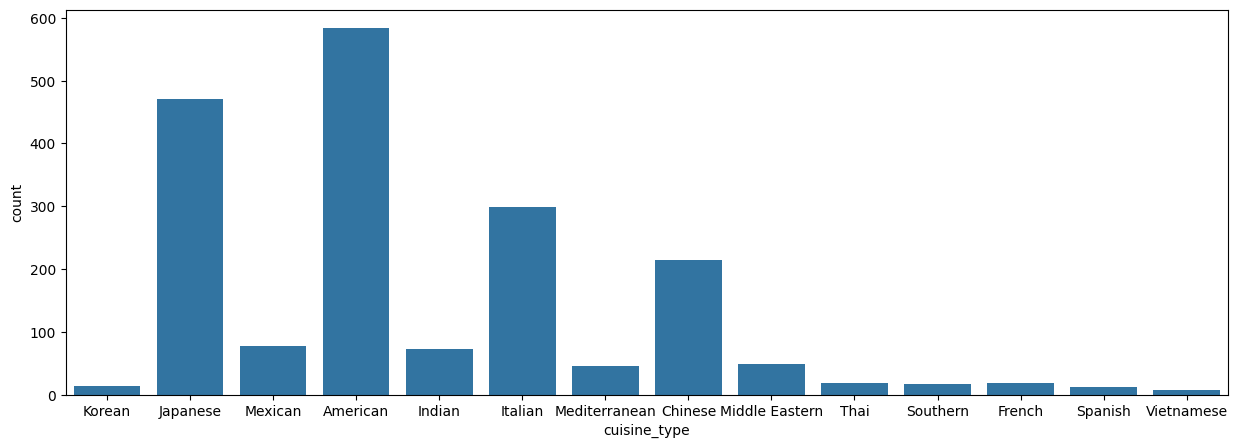

In [ ]:
plt.figure(figsize=(15, 5))
sns.countplot(data = df, x = 'cuisine_type')

#### Observations
- There are 14 unique cuisine types.
- The most frequently ordered cuisine type is **American**, followed by japanese
- The least ordered cuisine is vietnamese

#### Cost of the Order

In [ ]:
# Check unique cost of the order
df['cost_of_the_order'].nunique()

312

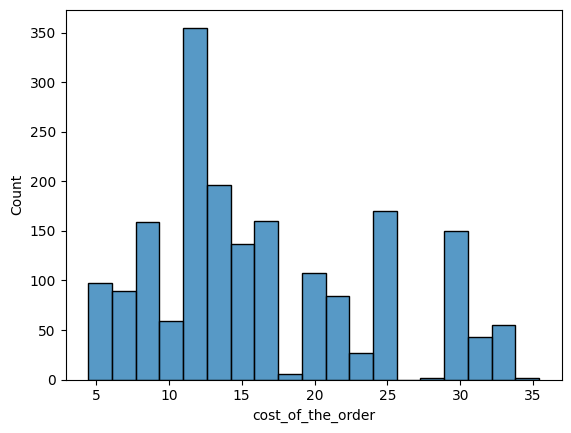

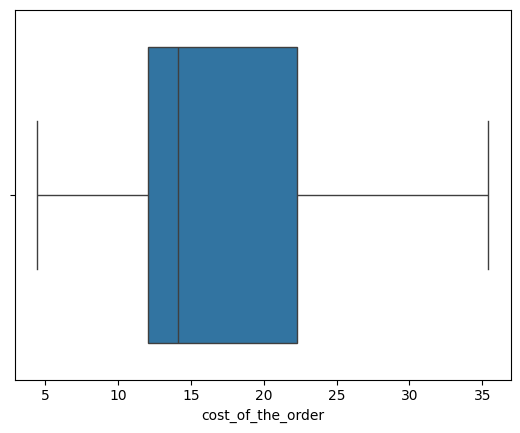

In [ ]:
sns.histplot(data = df, x = 'cost_of_the_order');
plt.show();
sns.boxplot(data = df, x = 'cost_of_the_order');
plt.show();

#### Observations
- There are few orders that cost greater than 30 dollars.
- The average cost of the order is greater than the median cost indicating that the distribution for the cost of the order is right-skewed

#### Day of the Week

In [ ]:
# Check unique day of the week
df['day_of_the_week'].value_counts()

,count
day_of_the_week,
Weekend,1351
Weekday,547


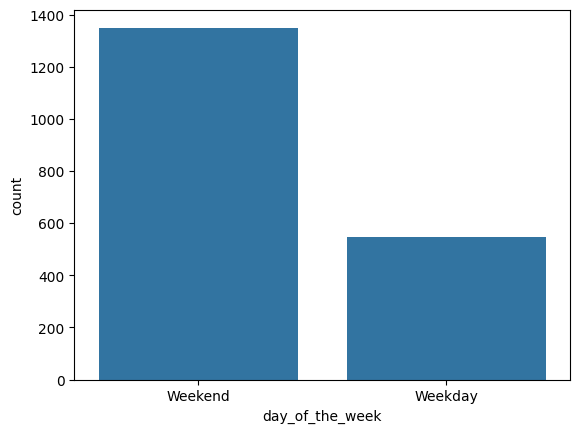

In [ ]:
sns.countplot(data = df, x = 'day_of_the_week');
plt.show();

#### Observations
- There are two (2) unique values for 'day_of_the_week' - Weekday & Weekend.
- The number of orders placed on weekends (1351) is significantly higher than on weekdays (547).
- This indicates that customer activity or demand increases substantially during weekends — approximately 2.5 times more orders compared to weekdays.
- Possible reasons could include customers having more free time, weekend promotions, or higher leisure/spending behavior on weekends.

#### Rating


In [ ]:
# Check unique rating
df['rating'].value_counts()

,count
rating,
5,588
4,386
3,188


<Axes: xlabel='rating', ylabel='count'>

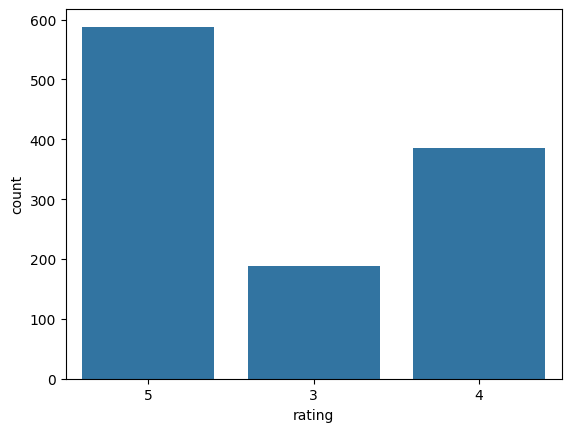

In [ ]:
sns.countplot(data = df, x = 'rating')

#### Observations
- The majority of ratings are 5 stars (588), which is about 50.6% of all ratings.

- 4-star ratings (386) make up around 33.2%, while 3-star ratings (188) account for 16.2%.

- This indicates that most customers are highly satisfied, with nearly 84% of ratings being 4 stars or higher.

#### Food Preparation Time

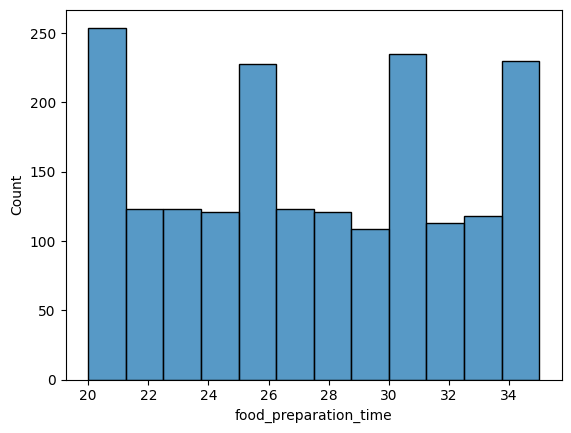

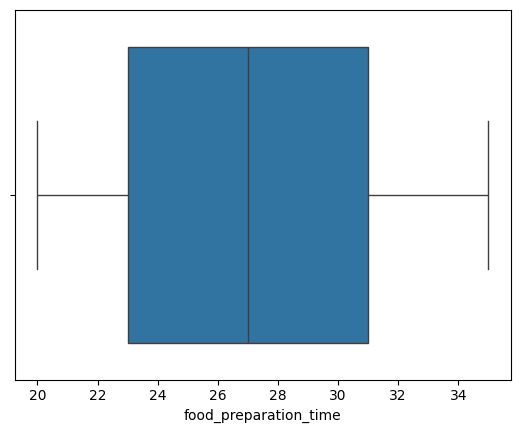

In [ ]:
sns.histplot(data = df, x = 'food_preparation_time');
plt.show();
sns.boxplot(data = df, x = 'food_preparation_time');
plt.show();


#### Observations
- The food preparation times range roughly from 20 to 35 minutes.

- The counts are fairly evenly spread, suggesting there’s no strong skew—preparation times are quite balanced across this range.

- Slight peaks appear around 20, 26, 30, and 34 minutes, where the number of orders is relatively higher.

- The most common preparation time seems to be around 20 minutes, with the highest count (≈250 orders).

#### Delivery Time

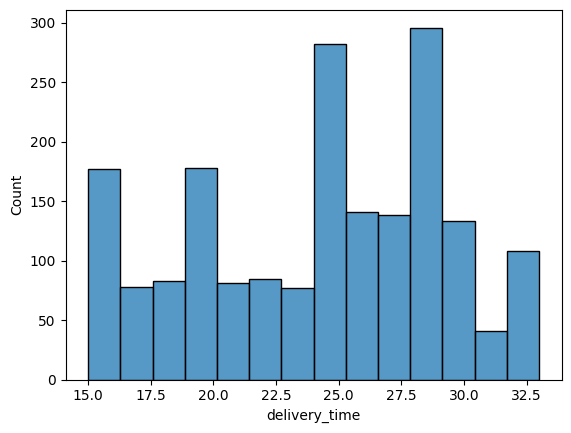

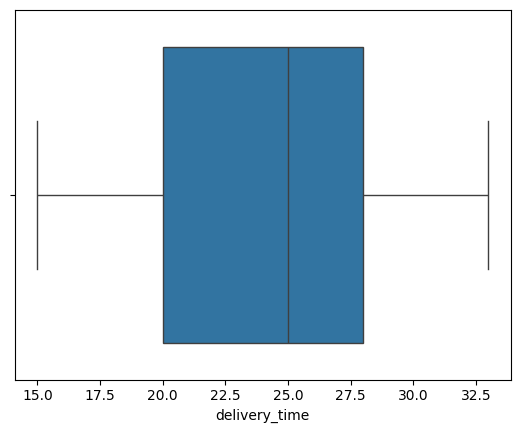

In [ ]:
sns.histplot(data = df, x = 'delivery_time');
plt.show();
sns.boxplot(data = df, x = 'delivery_time');
plt.show();

#### Observations
- Delivery times range approximately from 15 to 33 minutes.

- There are a few peaks around 20, 25, and 28 minutes, where the number of deliveries is relatively higher.

- The highest counts occur around 25–28 minutes, indicating that most deliveries take about that long.

- The data doesn’t show strong skewness — it’s fairly spread out, but there may be a slight right skew, suggesting a few longer delivery times.
- Most deliveries are completed between 20 and 28 minutes, with a typical (median) time of about 25 minutes. The spread is moderate, showing a stable and efficient delivery process.

### **Question 7**: Which are the top 5 restaurants in terms of the number of orders received? [1 mark]

In [ ]:
# get top 5 restaurants based on orders
df['restaurant_name'].value_counts()[:5]

,count
restaurant_name,
Shake Shack,219
The Meatball Shop,132
Blue Ribbon Sushi,119
Blue Ribbon Fried Chicken,96
Parm,68


#### Observations:
- Shake Shack received the highest number of orders, making it the most popular restaurant.

- The Meatball Shop and Blue Ribbon Sushi follow as the next most ordered restaurants.

- There is a gradual decrease in order counts from Shake Shack to Parm.

- The top restaurants mainly serve American-style comfort food, showing strong customer preference for casual dining

- The top 5 restaurants account for a large portion of total orders, showing a concentration of customer preference among a few popular places.

### **Question 8**: Which is the most popular cuisine on weekends? [1 mark]

In [ ]:
# Get the most popular cuisine on weekeends
df_weekend = df[df['day_of_the_week'] == 'Weekend']
df_weekend['cuisine_type'].value_counts()

,count
cuisine_type,
American,415
Japanese,335
Italian,207
Chinese,163
Mexican,53
Indian,49
Middle Eastern,32
Mediterranean,32
Thai,15


#### Observations:
- The most popular cuisine on weekends is American, with 415 orders.

- Japanese (335) and Italian (207) cuisines follow, indicating they are also highly preferred.

- There is a strong dominance of American cuisine, showing customers favor familiar and comfort-style foods during weekends.

- Cuisines like Chinese, Mexican, and Indian have moderate popularity, while others such as Vietnamese, Spanish, and Korean are less common.

- The data suggests that weekend dining trends lean heavily toward American and Asian cuisines, with customers opting for recognizable and easy-to-enjoy meals.

### **Question 9**: What percentage of the orders cost more than 20 dollars? [2 marks]

In [ ]:

# get orders that cost above 20 dollars
df_greater_than_20 = df[df['cost_of_the_order'] > 20]
print('The total number of order that cost more than 20 dollars is ', df_greater_than_20.shape[0])

# get percentage of orders that cost more than 20 dollars
df_percentage = df_greater_than_20.shape[0] / df.shape[0] * 100;
print('The percentage of orders that cost more than 20 dollars is ', round(df_percentage, 2), '%')

The total number of order that cot more than 20 dollars is  555
The percentage of orders that cost more than 20 dollars is  29.24 %


#### Observations:
- About 29% of all orders cost more than 20 dollars, indicating that the majority of orders (around 71%) are below 20 dollars. This suggests that most customers prefer affordable or moderately priced meals, while a smaller portion opts for higher-value orders.

### **Question 10**: What is the mean order delivery time? [1 mark]

In [ ]:
# get the mean order delivery time
df_delivery_time_mean = df['delivery_time'].mean()
print('The mean order delivery time is ', round(df_delivery_time_mean, 2), ' minutes')

The mean order delivery time is  24.16  minutes


#### Observations:
The mean order delivery time is  24.16  minutes

### **Question 11:** The company has decided to give 20% discount vouchers to the top 3 most frequent customers. Find the IDs of these customers and the number of orders they placed. [1 mark]

In [ ]:
# get the IDs of top three customers and number of orders they have placed
df['customer_id'].value_counts()[:3]

,count
customer_id,
52832,13
47440,10
83287,9


#### Observations:
- Customer 52832 is the most frequent, placing 13 orders.

- Customers 47440 and 83287 follow with 10 and 9 orders, respectively.

- These three customers represent the highest individual order activity, indicating strong repeat engagement or loyalty.

### Multivariate Analysis

### **Question 12**: Perform a multivariate analysis to explore relationships between the important variables in the dataset. (It is a good idea to explore relations between numerical variables as well as relations between numerical and categorical variables) [10 marks]


#### Cuisine vs Cost of the Order

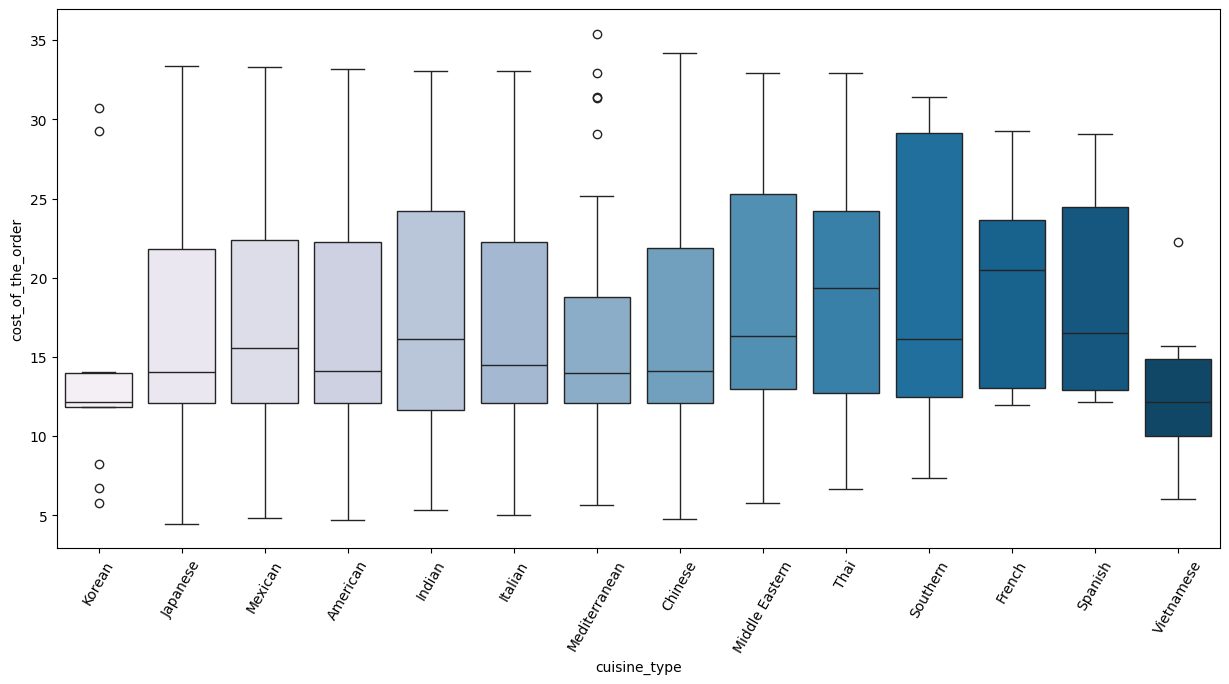

In [ ]:
# Relationship between cost of the order and cuisine type
plt.figure(figsize=(15, 7))
sns.boxplot(data = df, x = 'cuisine_type', y = 'cost_of_the_order', palette='PuBu', hue='cuisine_type')
plt.xticks(rotation=60)
plt.show();


#### Observations
- Vietnamese and Korean cuisines cost less compared to other cuisines,

- The boxplots for Italian, American, Chinese, Japanese cuisines are quite similar. This indicates that the quartile costs for these cuisines are quite similar.

- Outliers are present for the cost of Korean, Mediterranean and Vietnamese cuisines..

- French and Spanish cuisines are costlier compared to other cuisines

#### Cuisine vs Food Preparation Time

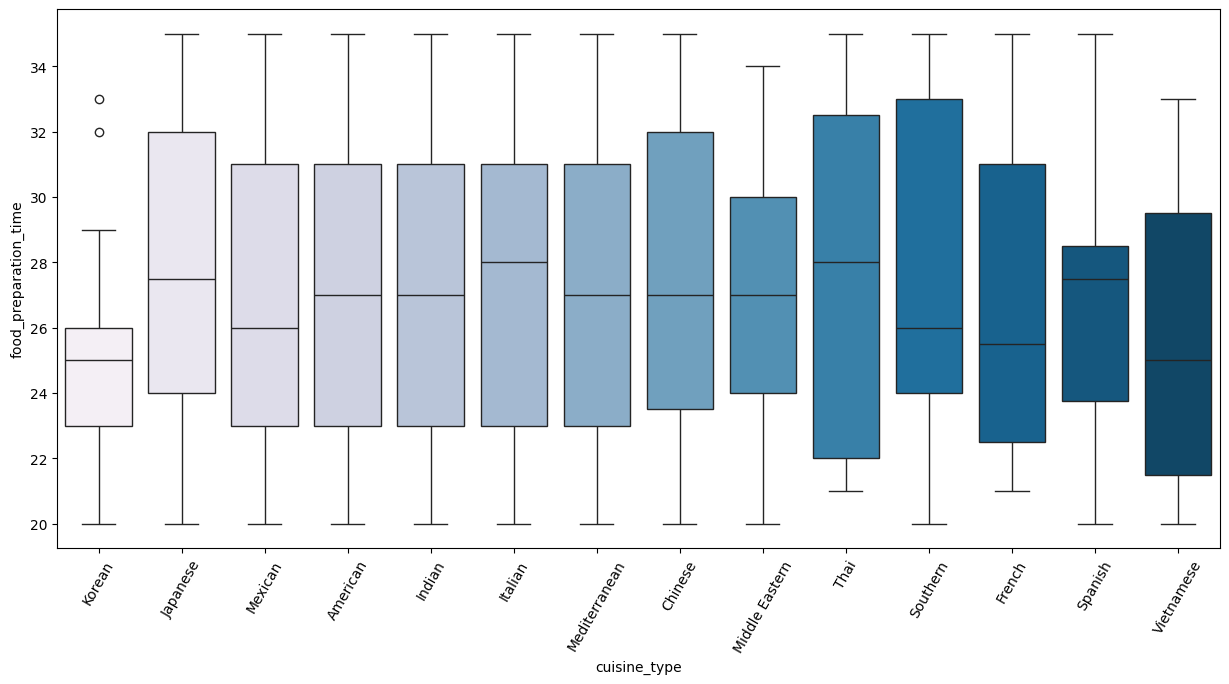

In [ ]:
# Relationship between food preparation time and cuisine type
plt.figure(figsize=(15, 7))
sns.boxplot(data = df, x = 'cuisine_type', y = 'food_preparation_time', palette='PuBu', hue='cuisine_type')
plt.xticks(rotation=60)
plt.show();


#### Observations:

- Food preparation time is very consistent for most of the cuisines.

- The median food preparation time lies between 24 and 30 minutes for all the cuisines.

- Outliers are present for the food preparation time of Korean cuisine.

- Korean cuisine takes less time compared to the other cuisines.

#### Day of the Week vs Delivery Time

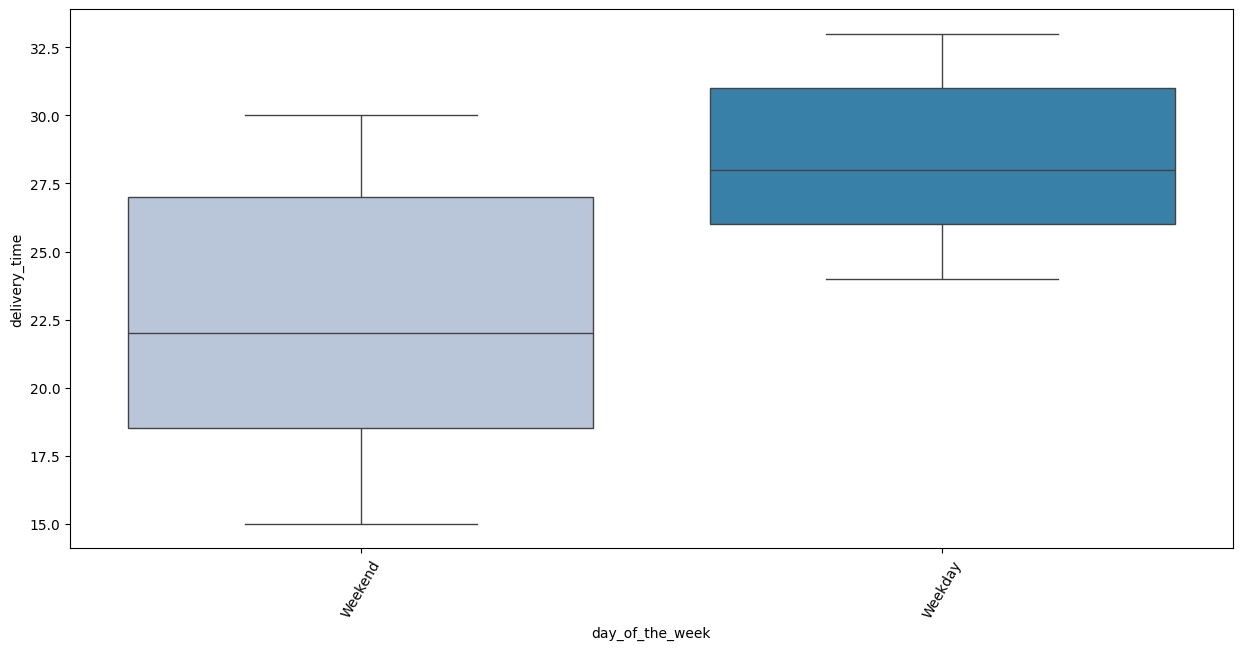

In [ ]:
# Relationship between day of the week and delivery time
plt.figure(figsize=(15, 7))
sns.boxplot(data = df, x = 'day_of_the_week', y = 'delivery_time', palette='PuBu', hue='day_of_the_week')
plt.xticks(rotation=60)
plt.show();


#### Observations
- The delivery time for all the orders over the weekends is less compared to weekdays. This could be due to the dip in traffic over the weekends.

#### Revenue Generated by the restaurants

In [ ]:
plt.figure(figsize=(15, 7))
df.groupby('restaurant_name')['cost_of_the_order'].sum().sort_values(ascending=False).head(14)

,cost_of_the_order
restaurant_name,
Shake Shack,3579.53
The Meatball Shop,2145.21
Blue Ribbon Sushi,1903.95
Blue Ribbon Fried Chicken,1662.29
Parm,1112.76
RedFarm Broadway,965.13
RedFarm Hudson,921.21
TAO,834.50
Han Dynasty,755.29


<Figure size 1500x700 with 0 Axes>

#### Observations
- The above 14 restaurant generate more than 500 dollars in revenue

#### Rating vs Delivery Time

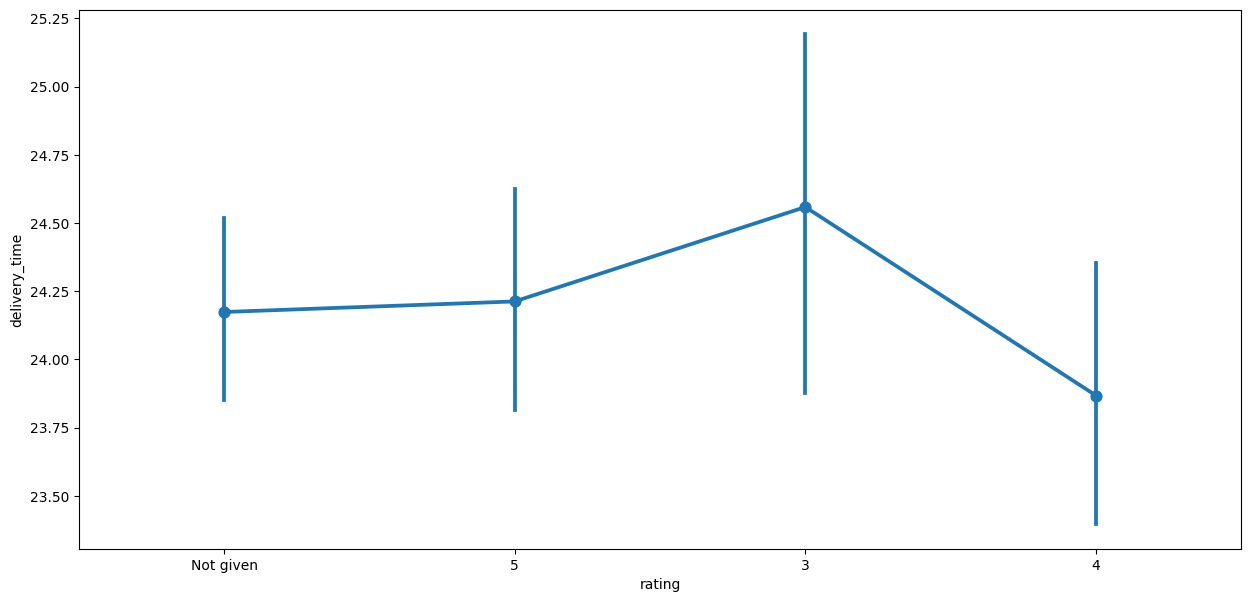

In [ ]:
# relationship between rating and delivery time
plt.figure(figsize=(15, 7))
sns.pointplot(data = df, x = 'rating', y = 'delivery_time')
plt.show();

#### Observations
- It is possible that delivery time play role in the low rating of orders

#### Correlation among variables

<Axes: >

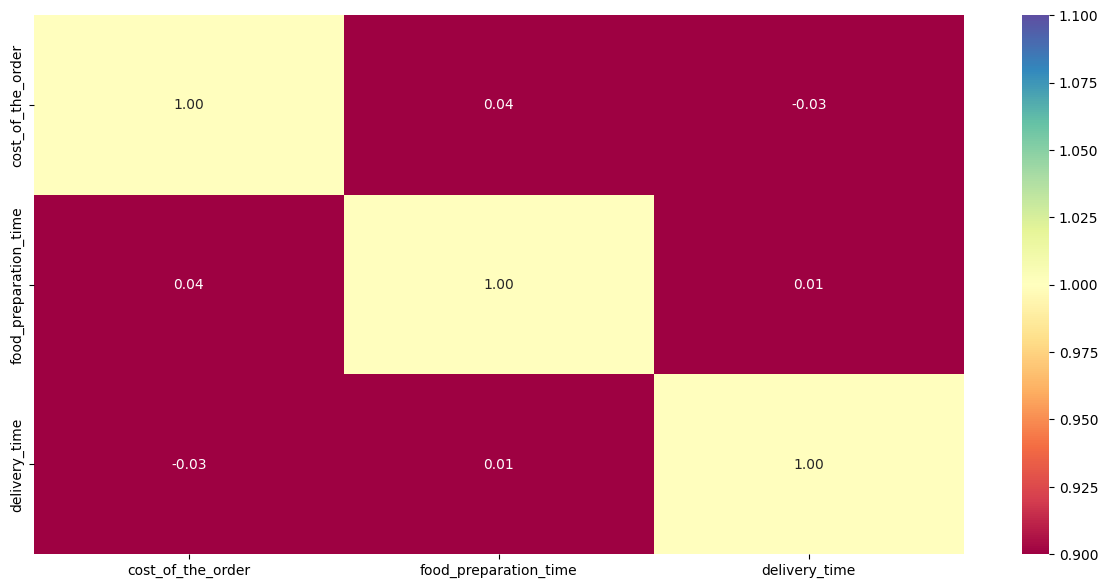

In [ ]:
# plot the heatmap
column_list = ['cost_of_the_order','food_preparation_time','delivery_time']
plt.figure(figsize=(15, 7))
sns.heatmap(df[column_list].corr(), annot=True, vmin = 1, vmax=1, fmt=".2f", cmap="Spectral")


#### Observations
-  There is no correllation between the cost of the order, delivery time and food preparation time

### **Question 13:** The company wants to provide a promotional offer in the advertisement of the restaurants. The condition to get the offer is that the restaurants must have a rating count of more than 50 and the average rating should be greater than 4. Find the restaurants fulfilling the criteria to get the promotional offer. [3 marks]

In [10]:
# Filter rated restaurants
df_rated = df[df['rating'] != 'Not given'].copy()
df_rated['rating'] = df_rated['rating'].astype('int')
df_rating_count = df_rated.groupby('restaurant_name')['rating'].count().sort_values(ascending=False).reset_index()
df_rating_count.head()

,restaurant_name,rating
0,Shake Shack,133
1,The Meatball Shop,84
2,Blue Ribbon Sushi,73
3,Blue Ribbon Fried Chicken,64
4,RedFarm Broadway,41


In [11]:
#get the restaurant names that have rating count more than 50
rest_names = df_rating_count[df_rating_count['rating'] > 50]['restaurant_name']

# filter to get the data of restaurants that have rating count more than 50
df_mean_4 = df_rated[df_rated['restaurant_name'].isin(rest_names)].copy()

# find the mean rating of the restaurants
df_mean_4_rating = df_mean_4.groupby(df_mean_4['restaurant_name'])['rating'].mean().sort_values(ascending = False).reset_index()

#filter for average rating greater than 4
df_avg_rating_greater_than_4 = df_mean_4_rating[df_mean_4_rating['rating'] > 4].sort_values(by='rating', ascending=False).reset_index(drop=True)
df_avg_rating_greater_than_4

,restaurant_name,rating
0,The Meatball Shop,4.511905
1,Blue Ribbon Fried Chicken,4.328125
2,Shake Shack,4.278195
3,Blue Ribbon Sushi,4.219178


#### Observations:
The restaurants fulfilling the criteria to et the promotional offers are: **The Meatball Shop**,	**Blue Ribbon Fried Chicken**	,
**Shake Shack**,
**Blue Ribbon Sushi**

### **Question 14:** The company charges the restaurant 25% on the orders having cost greater than 20 dollars and 15% on the orders having cost greater than 5 dollars. Find the net revenue generated by the company across all orders. [3 marks]

In [14]:
# function to determine revenue
def compute_revenue(cost_of_the_order):
  if cost_of_the_order > 20:
    return cost_of_the_order * 0.25
  elif cost_of_the_order > 5:
    return cost_of_the_order * 0.15
  else:
    return 0

df['revenue'] = df['cost_of_the_order'].apply(compute_revenue)
df['revenue'].sum()
df.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time,revenue
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20,7.6875
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23,1.8120
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28,1.8345
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15,7.3000
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24,1.7385


In [15]:
# get the total revenue and print it
total_revenue = df['revenue'].sum()
print('The total revenue generated by the company across all orders is ', round(total_revenue, 2), 'dollars')

The total revenue generated by the company across all orders is  6166.3 dollars


#### Observations:
The total revenue generated by the company across all orders is  6166.3 dollars

### **Question 15:** The company wants to analyze the total time required to deliver the food. What percentage of orders take more than 60 minutes to get delivered from the time the order is placed? (The food has to be prepared and then delivered.) [2 marks]

In [16]:
# Add a new column to the dataframe df to store total delivery time
df['total_delivery_time'] = df['food_preparation_time'] + df['delivery_time']

# Find the percentage (%) of orders whose total dlivery time is greater than 60 minutes
df_total_delivery_time_greater_than_60 = df[df['total_delivery_time'] > 60]
print('The percentage of orders that take more than 60 minutes to get delivered', round(df_total_delivery_time_greater_than_60.shape[0] / df.shape[0] * 100, 2), '%')

The percentage of orders that take more than 60 minutes to get delivered 10.54 %


#### Observations:
The percentage of orders that take more than 60 minutes to get delivered 10.54 %


### **Question 16:** The company wants to analyze the delivery time of the orders on weekdays and weekends. How does the mean delivery time vary during weekdays and weekends? [2 marks]

In [17]:
# get the mean delivery time on weekdays
df_weekday = df[df['day_of_the_week'] == 'Weekday']
df_weekday['delivery_time'].mean()
print('The mean delivery time on weekdays is ', round(df_weekday['delivery_time'].mean(), 2), ' minutes')

# get the mean delivery time on weekends
df_weekend = df[df['day_of_the_week'] == 'Weekend']
df_weekend['delivery_time'].mean()
print('The mean delivery time on weekends is ', round(df_weekend['delivery_time'].mean(), 2), ' minutes')


The mean delivery time on weekdays is  28.34  minutes
The mean delivery time on weekends is  22.47  minutes


#### Observations:
- The mean delivery time on weekdays is  28.34  minutes
- The mean delivery time on weekends is  22.47  minutes


### Conclusion and Recommendations

### **Question 17:** What are your conclusions from the analysis? What recommendations would you like to share to help improve the business? (You can use cuisine type and feedback ratings to drive your business recommendations.) [6 marks]

### Conclusions:
*  1,898 orders from 178 restaurants; total revenue $6,166.3.

* 71% of orders cost < $20, showing a preference for affordable meals.

* American cuisine is most popular; Vietnamese and Korean least ordered.

* Shake Shack, The Meatball Shop, and Blue Ribbon Sushi lead in orders.

* Weekend orders (1351) are 2.5× higher than weekdays — demand peaks on weekends.

* Avg. prep: 27 min; avg. delivery: 24 min. Weekends have faster deliveries.

* 39% of orders lack ratings; of rated ones, 84% are 4★+ (high satisfaction).

* 10.5% of orders take >60 min — possible cause of low ratings.

* No clear link between cost, prep time, and delivery time

### Recommendations:

*  Encourage feedback (offer small rewards for ratings) to reduce “Not given” entries.

* Improve delivery efficiency — focus on weekday delays and >60-min orders.

* Reward loyal customers (e.g., Customer 52832) via loyalty programs.

* Promote top restaurants and use them in marketing campaigns.

* Expand less-ordered cuisines (Vietnamese, Korean) through promotions or combo deals.

* Leverage weekends — add “Weekend Specials” and boost delivery staff.

* Review pricing of French/Spanish cuisines to ensure value perception.

---